### 2.1 理论计算题

#### 1. 非线性激活函数的重要性

**证明：**

给定单隐藏层MLP：
- 隐藏层（无激活函数）：$\mathbf{h} = \mathbf{W}_1\mathbf{x} + \mathbf{b}_1$
- 输出层：$\mathbf{o} = \mathbf{W}_2\mathbf{h} + \mathbf{b}_2$

代入得：
$$\mathbf{o} = \mathbf{W}_2(\mathbf{W}_1\mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = \mathbf{W}_2\mathbf{W}_1\mathbf{x} + \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$$

令：
$$\mathbf{W}' = \mathbf{W}_2\mathbf{W}_1, \quad \mathbf{b}' = \mathbf{W}_2\mathbf{b}_1 + \mathbf{b}_2$$

则：
$$\mathbf{o} = \mathbf{W}'\mathbf{x} + \mathbf{b}'$$

这是一个单层神经网络（线性变换），没有增加任何表达能力。**因此，没有非线性激活函数的多层网络等价于单层网络。**

---

#### 2. 激活函数性质分析

**Sigmoid函数：**
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

导数：
$$\sigma'(x) = \sigma(x)(1 - \sigma(x))$$

**tanh函数：**
$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

导数：
$$\tanh'(x) = 1 - \tanh^2(x)$$

两者导数都可以用自身表示，便于反向传播计算。

---

### 2.2 编程题

epoch 1
train loss: 2.2905
test acc: 0.2021
epoch 2
train loss: 2.2570
test acc: 0.2228
epoch 3
train loss: 2.2018
test acc: 0.2856
epoch 4
train loss: 2.1129
test acc: 0.3939
epoch 5
train loss: 1.9840
test acc: 0.4786
epoch 6
train loss: 1.8258
test acc: 0.5075
epoch 7
train loss: 1.6684
test acc: 0.5574
epoch 8
train loss: 1.5313
test acc: 0.5730
epoch 9
train loss: 1.4183
test acc: 0.5890
epoch 10
train loss: 1.3250
test acc: 0.5963


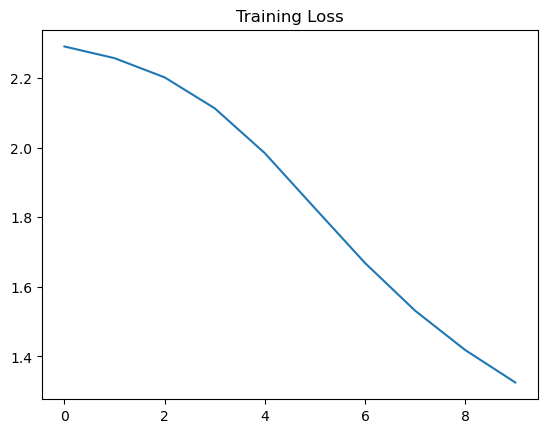

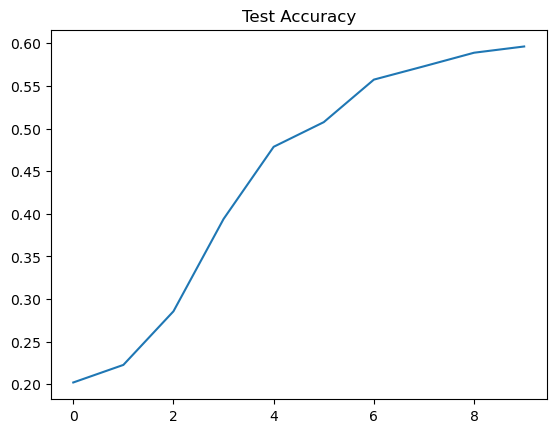

In [1]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# -------------------------
# 1. 加载 Fashion-MNIST
# -------------------------
batch_size = 256

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

# -------------------------
# 2. 手动初始化参数
# -------------------------
num_inputs = 784
num_hidden = 256
num_outputs = 10

W1 = torch.randn(num_inputs, num_hidden) * 0.01
b1 = torch.zeros(num_hidden)

W2 = torch.randn(num_hidden, num_outputs) * 0.01
b2 = torch.zeros(num_outputs)

params = [W1, b1, W2, b2]

for param in params:
    param.requires_grad_(True)

# -------------------------
# 3. ReLU 激活函数
# -------------------------
def relu(X):
    return torch.max(X, torch.tensor(0.0))

# -------------------------
# 4. Softmax
# -------------------------
def softmax(X):
    X_exp = torch.exp(X - X.max(dim=1, keepdim=True).values)
    partition = X_exp.sum(dim=1, keepdim=True)
    return X_exp / partition

# -------------------------
# 5. 模型定义
# -------------------------
def net(X):
    X = X.reshape((-1, 784))
    H = relu(X @ W1 + b1)
    return softmax(H @ W2 + b2)

# -------------------------
# 6. 交叉熵损失
# -------------------------
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y]).mean()

# -------------------------
# 7. 准确率
# -------------------------
def accuracy(y_hat, y):
    pred = y_hat.argmax(dim=1)
    return (pred == y).float().mean()

# -------------------------
# 8. SGD
# -------------------------
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

# -------------------------
# 9. 训练
# -------------------------
num_epochs = 10
lr = 0.5

train_losses = []
test_accs = []

for epoch in range(num_epochs):

    total_loss = 0
    total_acc = 0
    count = 0

    for X, y in train_loader:

        y_hat = net(X)
        loss = cross_entropy(y_hat, y)

        loss.backward()

        sgd(params, lr, batch_size)

        total_loss += loss.item()
        total_acc += accuracy(y_hat, y).item()
        count += 1

    train_loss = total_loss / count

    # 测试集准确率
    test_acc = 0
    test_count = 0

    with torch.no_grad():
        for X, y in test_loader:
            y_hat = net(X)
            test_acc += accuracy(y_hat, y).item()
            test_count += 1

    test_acc /= test_count

    train_losses.append(train_loss)
    test_accs.append(test_acc)

    print(f"epoch {epoch+1}")
    print(f"train loss: {train_loss:.4f}")
    print(f"test acc: {test_acc:.4f}")

# -------------------------
# 10. 绘图
# -------------------------
plt.plot(train_losses)
plt.title("Training Loss")
plt.show()

plt.plot(test_accs)
plt.title("Test Accuracy")
plt.show()

## 3 模型选择、权重衰减和丢弃法

### 3.1 理论计算题

#### 1. 过拟合与欠拟合

**训练误差 vs 泛化误差：**
- **训练误差**：模型在训练数据上的误差
- **泛化误差**：模型在未见过的测试数据上的期望误差

当训练误差极低但泛化误差很高时，模型处于**过拟合**状态。

**缓解方法：**
- 减少模型复杂度（减少层数/神经元数）
- 增加训练数据
- 正则化（L1/L2正则化、Dropout）
- 早停

---

#### 2. K折交叉验证

**算法步骤：**

1. 将数据集随机划分为K个大小相等的子集
2. 对于 k = 1 到 K：
   - 将第k个子集作为验证集
   - 其余K-1个子集合并作为训练集
   - 在训练集上训练模型，在验证集上评估
3. 计算K次验证结果的平均值作为最终性能指标
4. 可选择性能最好的模型在整个数据集上重新训练

---

### 3.2 编程题

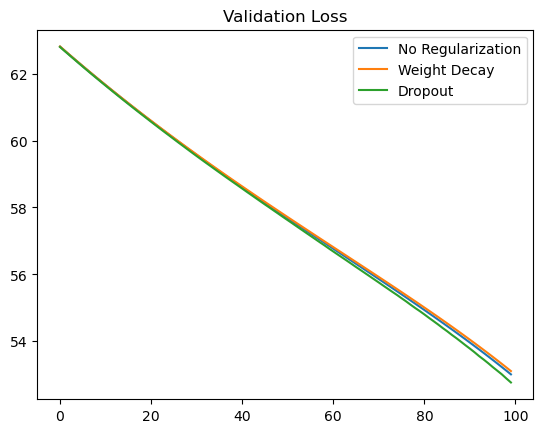

In [2]:
import torch
import matplotlib.pyplot as plt

# -------------------------
# 1. 构造少量样本
# -------------------------
n_train = 20
n_test = 100

true_w = torch.tensor([1.2, -3.4, 5.6])
true_b = 5.0

X = torch.randn((n_train + n_test, 3))
y = X @ true_w + true_b
y += torch.randn(y.shape) * 0.1

X_train = X[:n_train]
y_train = y[:n_train]

X_test = X[n_train:]
y_test = y[n_train:]

# -------------------------
# 2. Dropout
# -------------------------
def dropout_layer(X, dropout):

    assert 0 <= dropout <= 1

    if dropout == 1:
        return torch.zeros_like(X)

    if dropout == 0:
        return X

    mask = (torch.rand(X.shape) > dropout).float()

    return mask * X / (1.0 - dropout)

# -------------------------
# 3. 初始化参数
# -------------------------
num_inputs = 3
num_hidden = 256
num_outputs = 1

def init_params():
    W1 = torch.randn(num_inputs, num_hidden) * 0.01
    b1 = torch.zeros(num_hidden)

    W2 = torch.randn(num_hidden, num_outputs) * 0.01
    b2 = torch.zeros(num_outputs)

    params = [W1, b1, W2, b2]

    for param in params:
        param.requires_grad_(True)

    return params

# -------------------------
# 4. 模型
# -------------------------
def relu(X):
    return torch.max(X, torch.tensor(0.0))

def net(X, params, dropout=0.0, is_training=True):

    W1, b1, W2, b2 = params

    H = relu(X @ W1 + b1)

    if is_training:
        H = dropout_layer(H, dropout)

    return H @ W2 + b2

# -------------------------
# 5. loss
# -------------------------
def mse_loss(y_hat, y):
    return ((y_hat.reshape(y.shape) - y) ** 2).mean()

# -------------------------
# 6. SGD + weight decay
# -------------------------
def sgd(params, lr, wd, batch_size):

    with torch.no_grad():

        for param in params:

            param *= (1 - lr * wd)

            param -= lr * param.grad / batch_size

            param.grad.zero_()

# -------------------------
# 7. 训练函数
# -------------------------
def train_model(wd=0.0, dropout=0.0):

    params = init_params()

    train_losses = []
    test_losses = []

    lr = 0.05
    epochs = 100

    for epoch in range(epochs):

        y_hat = net(X_train, params, dropout, True)

        loss = mse_loss(y_hat, y_train)

        loss.backward()

        sgd(params, lr, wd, n_train)

        with torch.no_grad():

            train_l = mse_loss(
                net(X_train, params, dropout, False),
                y_train
            ).item()

            test_l = mse_loss(
                net(X_test, params, dropout, False),
                y_test
            ).item()

        train_losses.append(train_l)
        test_losses.append(test_l)

    return train_losses, test_losses

# -------------------------
# 8. 三种实验
# -------------------------
train1, test1 = train_model(wd=0.0, dropout=0.0)

train2, test2 = train_model(wd=0.01, dropout=0.0)

train3, test3 = train_model(wd=0.0, dropout=0.5)

# -------------------------
# 9. 绘图
# -------------------------
plt.plot(test1, label='No Regularization')

plt.plot(test2, label='Weight Decay')

plt.plot(test3, label='Dropout')

plt.legend()

plt.title("Validation Loss")

plt.show()

## 4 数值稳定性与激活函数

### 4.1 理论计算题

#### 1. 梯度消失与梯度爆炸

**梯度爆炸条件：**
- 权重矩阵的谱半径 > 1
- 激活函数导数 > 1（如某些区间）
- 多层连乘导致梯度指数级增长

**梯度消失条件：**
- 权重矩阵的谱半径 < 1
- 激活函数导数 < 1（如Sigmoid在饱和区导数接近0）
- 多层连乘导致梯度指数级衰减

#### 2. ReLU缓解梯度消失的原因

- ReLU导数：1（正区间）或 0（负区间）
- 正区间梯度恒为1，不会衰减
- 负区间虽梯度为0，但保留了部分路径
- 不像Sigmoid最大值仅0.25，连乘后快速消失

---

### 4.2 编程题


In [3]:
import torch
import torch.nn as nn

# -------------------------
# 1. 深层网络
# -------------------------
def build_network(activation):

    layers = []

    input_size = 256

    for _ in range(20):

        layers.append(nn.Linear(input_size, 256))
        layers.append(activation())

    layers.append(nn.Linear(256, 10))

    return nn.Sequential(*layers)

# -------------------------
# 2. 打印梯度
# -------------------------
def print_gradients(model):

    for i, layer in enumerate(model):

        if isinstance(layer, nn.Linear):

            grad_norm = layer.weight.grad.norm().item()

            print(f"Layer {i} grad norm: {grad_norm}")

# -------------------------
# 3. Sigmoid + 普通初始化
# -------------------------
model = build_network(nn.Sigmoid)

for m in model:

    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1)

X = torch.randn(64, 256)

y = torch.randn(64, 10)

criterion = nn.MSELoss()

output = model(X)

loss = criterion(output, y)

loss.backward()

print("Sigmoid + Normal Init")
print_gradients(model)

# -------------------------
# 4. ReLU + 大初始化
# -------------------------
model = build_network(nn.ReLU)

for m in model:

    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=10)

X = torch.randn(64, 256)

output = model(X)

loss = criterion(output, y)

loss.backward()

print("\nReLU + Large Init")
print_gradients(model)

# -------------------------
# 5. Xavier + ReLU
# -------------------------
model = build_network(nn.ReLU)

for m in model:

    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)

X = torch.randn(64, 256)

output = model(X)

loss = criterion(output, y)

loss.backward()

print("\nXavier + ReLU")
print_gradients(model)

Sigmoid + Normal Init
Layer 0 grad norm: 493.7167663574219
Layer 2 grad norm: 320.8318176269531
Layer 4 grad norm: 246.6166229248047
Layer 6 grad norm: 236.4734649658203
Layer 8 grad norm: 173.26300048828125
Layer 10 grad norm: 124.52617645263672
Layer 12 grad norm: 117.21913146972656
Layer 14 grad norm: 109.55408477783203
Layer 16 grad norm: 82.30037689208984
Layer 18 grad norm: 73.45979309082031
Layer 20 grad norm: 60.04109573364258
Layer 22 grad norm: 42.653438568115234
Layer 24 grad norm: 34.728660583496094
Layer 26 grad norm: 29.598222732543945
Layer 28 grad norm: 27.939434051513672
Layer 30 grad norm: 26.933162689208984
Layer 32 grad norm: 26.4166202545166
Layer 34 grad norm: 26.223854064941406
Layer 36 grad norm: 30.98491859436035
Layer 38 grad norm: 40.864097595214844
Layer 40 grad norm: 45.21372604370117

ReLU + Large Init
Layer 0 grad norm: nan
Layer 2 grad norm: nan
Layer 4 grad norm: nan
Layer 6 grad norm: nan
Layer 8 grad norm: nan
Layer 10 grad norm: nan
Layer 12 grad nor

## 5 泛化表现、协变量偏移和对抗性数据

### 5.1 理论计算题

**协变量偏移 (Covariate Shift)：**
- 特征分布变化：$p(\mathbf{x}) \neq q(\mathbf{x})$
- 条件标签分布不变：$p(y|\mathbf{x}) = q(y|\mathbf{x})$
- **例子**：医疗诊断中，训练数据来自三甲医院（重症患者多），测试数据来自社区医院（轻症患者多）。症状-疾病关系相同，但输入特征分布不同。

**标签偏移 (Label Shift)：**
- 标签分布变化：$p(y) \neq q(y)$
- 条件特征分布不变：$p(\mathbf{x}|y) = q(\mathbf{x}|y)$
- **例子**：电商推荐系统中，训练期用户购买电子产品比例高，测试期用户购买服装比例高。用户画像给定商品类别下的特征分布相同，但商品类别的先验分布变化。

**联系与区别：**
- 两者都是训练/测试分布不一致
- 区别：变化的是**输入分布**还是**输出分布**
- 协变量偏移需要估计$P_{test}(x)/P_{train}(x)$
- 标签偏移需要估计$P_{test}(y)/P_{train}(y)$

---

### 5.2 编程题

In [4]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)

# -------------------------
# 1. 构造数据集
# -------------------------
n_train = 1000
n_test = 500

# 训练集 P
X_train = torch.randn(n_train, 1) - 1

noise = torch.randn(n_train, 1) * 0.1

y_train = 2 * X_train + noise

# 测试集 Q
X_test = torch.randn(n_test, 1) + 2

noise_test = torch.randn(n_test, 1) * 0.1

y_test = 2 * X_test + noise_test

# -------------------------
# 2. 线性回归
# -------------------------
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.05

for epoch in range(200):

    y_hat = X_train * w + b

    loss = ((y_hat - y_train) ** 2).mean()

    loss.backward()

    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

        w.grad.zero_()
        b.grad.zero_()

# baseline mse
with torch.no_grad():

    pred = X_test * w + b

    baseline_mse = ((pred - y_test) ** 2).mean()

print("Baseline MSE:", baseline_mse.item())

# -------------------------
# 3. 构建分类器
# -------------------------
X_cls = torch.cat([X_train, X_test], dim=0)

y_cls = torch.cat([
    torch.zeros(n_train, 1),
    torch.ones(n_test, 1)
], dim=0)

wc = torch.randn(1, requires_grad=True)
bc = torch.zeros(1, requires_grad=True)

def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

for epoch in range(500):

    logits = X_cls * wc + bc

    prob = sigmoid(logits)

    loss = -(
        y_cls * torch.log(prob + 1e-8)
        + (1 - y_cls) * torch.log(1 - prob + 1e-8)
    ).mean()

    loss.backward()

    with torch.no_grad():

        wc -= lr * wc.grad
        bc -= lr * bc.grad

        wc.grad.zero_()
        bc.grad.zero_()

# -------------------------
# 4. 计算权重
# -------------------------
with torch.no_grad():

    p_test = sigmoid(X_train * wc + bc)

    p_train = 1 - p_test

    weights = p_test / (p_train + 1e-8)

# -------------------------
# 5. 加权线性回归
# -------------------------
w2 = torch.randn(1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

for epoch in range(200):

    pred = X_train * w2 + b2

    loss = (weights * (pred - y_train) ** 2).mean()

    loss.backward()

    with torch.no_grad():

        w2 -= lr * w2.grad
        b2 -= lr * b2.grad

        w2.grad.zero_()
        b2.grad.zero_()

# weighted mse
with torch.no_grad():

    pred = X_test * w2 + b2

    weighted_mse = ((pred - y_test) ** 2).mean()

print("Weighted MSE:", weighted_mse.item())

Baseline MSE: 0.010351463221013546
Weighted MSE: 0.019825370982289314
